Data Importation

In [18]:
import pandas as pd
df = pd.read_csv('football.csv')
df_comp=pd.read_csv("competition.csv")

Data Cleaning

In [19]:
df.isna().sum()

id                           0
date                         0
home_team                    0
away_team                    0
rank_change_home             0
rank_change_away          2042
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean         24
home_goals_suf_mean_l5       0
home_rank_mean               0
home_rank_mean_l5            0
home_points_mean            14
home_points_mean_l5          0
away_goals_mean              0
away_goals_mean_l5           0
away_goals_suf_mean         17
away_goals_suf_mean_l5       0
away_rank_mean               0
away_rank_mean_l5            0
away_points_mean             0
away_points_mean_l5          0
target                       0
match_type                   0
dtype: int64

In [20]:
df = df.drop(columns=['home_team','away_team','rank_change_away','id','date','match_type'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank_change_home        3777 non-null   float64
 1   home_goals_mean         3777 non-null   float64
 2   home_goals_mean_l5      3777 non-null   float64
 3   home_goals_suf_mean     3777 non-null   float64
 4   home_goals_suf_mean_l5  3777 non-null   float64
 5   home_rank_mean          3777 non-null   float64
 6   home_rank_mean_l5       3777 non-null   float64
 7   home_points_mean        3777 non-null   float64
 8   home_points_mean_l5     3777 non-null   float64
 9   away_goals_mean         3777 non-null   float64
 10  away_goals_mean_l5      3777 non-null   float64
 11  away_goals_suf_mean     3777 non-null   float64
 12  away_goals_suf_mean_l5  3777 non-null   float64
 13  away_rank_mean          3777 non-null   float64
 14  away_rank_mean_l5       3777 non-null   

In [22]:
df['home_goals_suf_mean'] = df['home_goals_suf_mean'].fillna(df['home_goals_suf_mean'].median())
df['home_points_mean'] = df['home_points_mean'].fillna(df['home_points_mean'].median())
df['away_goals_suf_mean'] = df['away_goals_suf_mean'].fillna(df['away_goals_suf_mean'].median())

Détection Outliers Feature

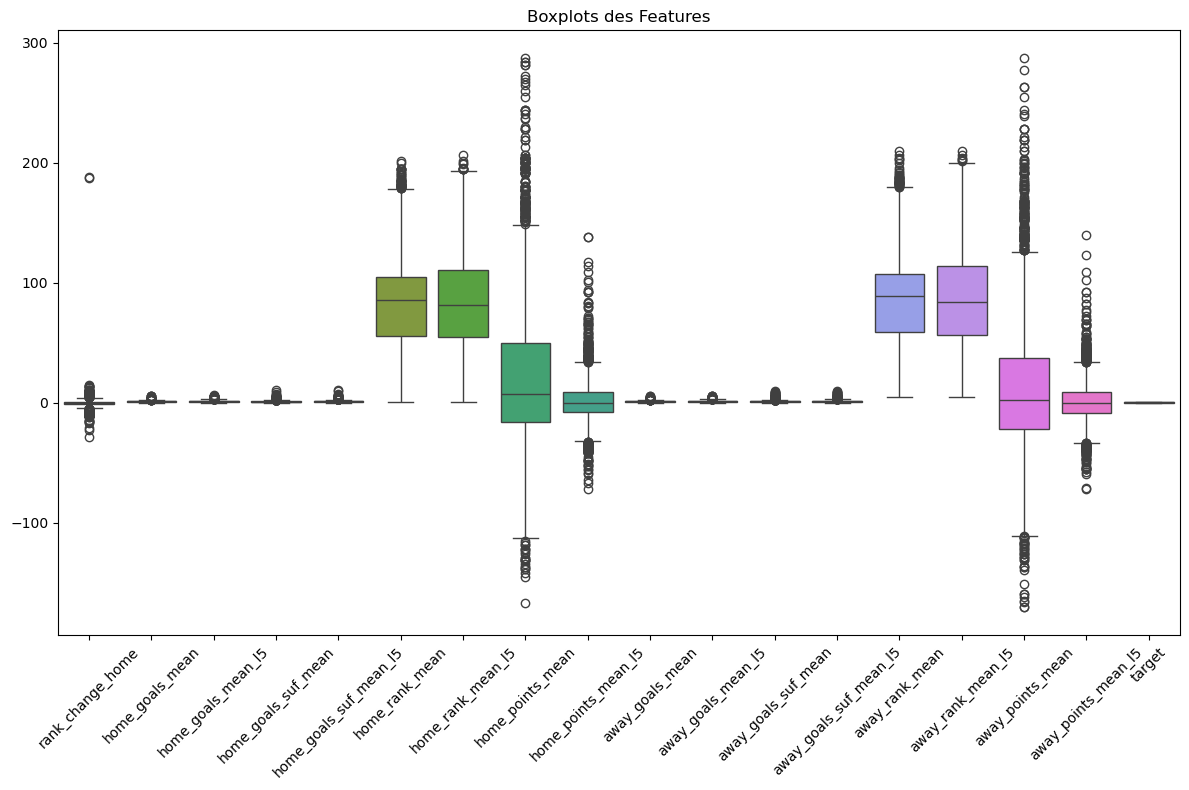

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.boxplot(data=df.select_dtypes(include=['number']))
plt.title('Boxplots des Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


IQR Outlier Detection

In [31]:

q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
abberantes = ((df < (q1 - 1.5*iqr)) | (df > (q3 + 1.5*iqr))).sum()
print(abberantes)

rank_change_home          1209
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean        151
home_goals_suf_mean_l5       0
home_rank_mean               1
home_rank_mean_l5            0
home_points_mean           112
home_points_mean_l5         65
away_goals_mean              4
away_goals_mean_l5           0
away_goals_suf_mean         32
away_goals_suf_mean_l5       0
away_rank_mean               1
away_rank_mean_l5            0
away_points_mean           127
away_points_mean_l5         90
target                       0
dtype: int64


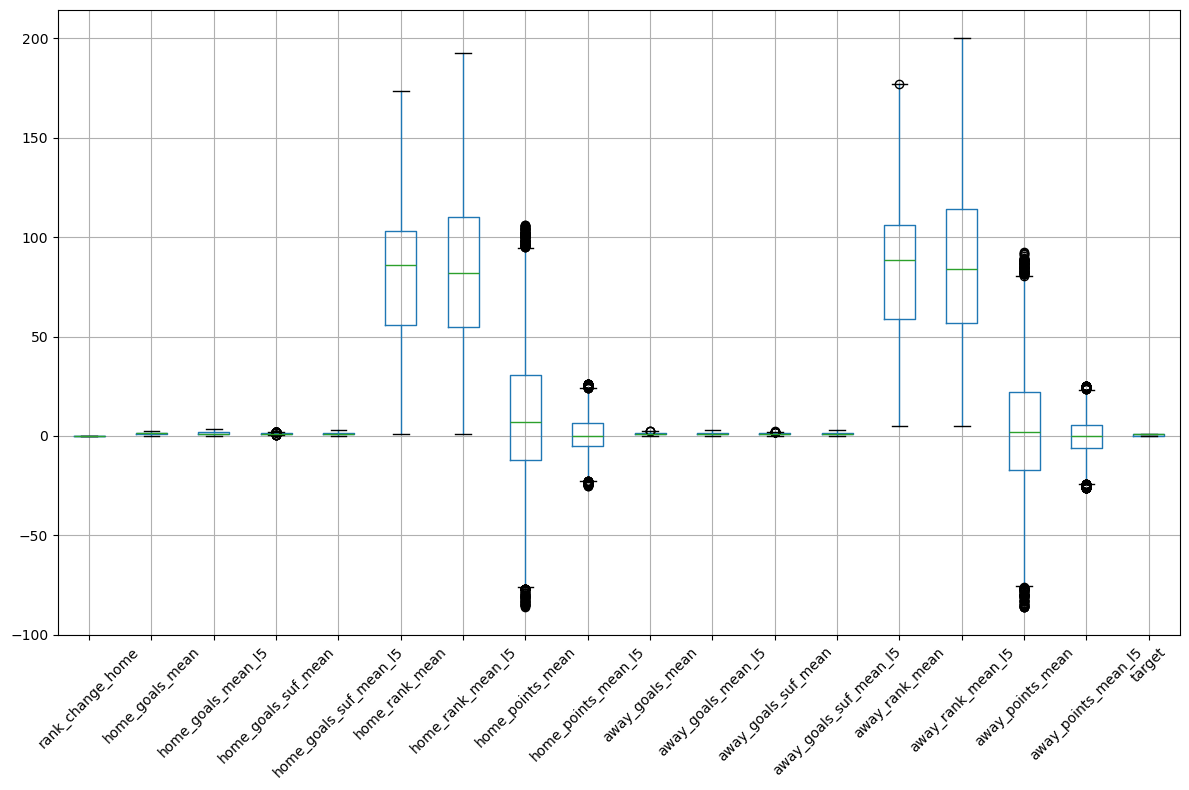

In [32]:
for col in df.columns:
    median = df[col].median()
    lower = q1[col] - 1.5*iqr[col]
    upper = q3[col] + 1.5*iqr[col]
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

df.boxplot(figsize=(12,8))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KNN Classification Pipeline

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, classification_report

x = df.drop(columns=['target'])
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=1, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ ACCURACY KNN: {accuracy:.3f}")
print("\n📊 Rapport détaillé:")
print(classification_report(y_test, y_pred))



✅ ACCURACY KNN: 0.655

📊 Rapport détaillé:
              precision    recall  f1-score   support

           0       0.66      0.58      0.61       360
           1       0.65      0.72      0.69       396

    accuracy                           0.65       756
   macro avg       0.65      0.65      0.65       756
weighted avg       0.65      0.65      0.65       756



KNN Confusion Matrix

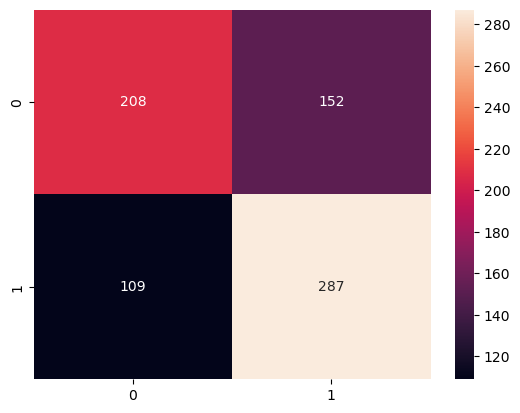

In [50]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

KNN Hyperparameter Tuning 

In [55]:
from sklearn.model_selection import cross_val_score
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x_train_scaled, y_train, cv=5).mean()
    scores.append(score)
best_k = scores.index(max(scores)) + 1
print(f"🚀 K optimal = {best_k} (score: {max(scores):.3f})")

🚀 K optimal = 15 (score: 0.663)


Data Cleaning Competition

In [41]:
df_comp = df_comp.drop(columns=['home_team','away_team','rank_change_away','match_type','date'])

KNN Model Deployment

In [45]:
x_comp = df_comp.drop(columns=['id'])
x_comp_scaled = scaler.transform(x_comp)
y_comp_pred = knn.predict(x_comp_scaled)

y_comp_pred = knn.predict(x_comp_scaled)


KNN Kaggle Submission

In [46]:
knnsoum = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred})
knnsoum.to_csv('submission_knn.csv', index=False)


Second Model Training

In [57]:
knn2 = KNeighborsClassifier(n_neighbors=15, algorithm='ball_tree', weights='distance', metric='manhattan')

cv_score = cross_val_score(knn2, x_train_scaled, y_train, cv=5)
print(f"🎯 KNN2 CV: {cv_score.mean():.3f} ± {cv_score.std():.3f}")

🎯 KNN2 CV: 0.659 ± 0.016


In [58]:
knn2.fit(x_train_scaled, y_train)
y_pred2 = knn2.predict(x_test_scaled)
print(f"✅ Accuracy finale: {accuracy_score(y_test, y_pred2):.3f}")
print("\n📊 Rapport détaillé:")
print(classification_report(y_test, y_pred2))

✅ Accuracy finale: 0.643

📊 Rapport détaillé:
              precision    recall  f1-score   support

           0       0.64      0.59      0.61       360
           1       0.65      0.69      0.67       396

    accuracy                           0.64       756
   macro avg       0.64      0.64      0.64       756
weighted avg       0.64      0.64      0.64       756



In [59]:
x_comp2 = df_comp.drop(columns=['id'])
x_comp_scaled2 = scaler.transform(x_comp2)
y_comp_pred2 = knn2.predict(x_comp_scaled2)

y_comp_pred2 = knn2.predict(x_comp_scaled2)

In [61]:
knnsoum = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred2})
knnsoum.to_csv('submission_knn2.csv', index=False)

Model KNN Number 3

Correlation Analysis

In [62]:
# CORRÉLATION + SUPPRESSION DÉTAILLÉE
print("🔍 Analyse corrélation avec 'target' (>0.10)...")

corr = df.corr()['target'].abs()
garder = corr[corr > 0.10].index.tolist()

# **NOUVEAU** : Liste des colonnes SUPPRIMÉES (correlation < 0.10)
supprimees = [col for col in df.columns if col not in garder]
print(f"\n❌ **COLONNES SUPPRIMÉES** (corr < 0.10):")
for col in supprimees:
    corr_val = corr[col]
    print(f"   → {col}: {corr_val:.3f}")

print(f"\n📊 {len(df.columns)} → {len(garder)} colonnes gardées")
print(f"🗑️  {len(supprimees)} colonnes supprimées")

# DataFrame nettoyé
df_clean = df[garder]
print("\n📈 Corrélations restantes (triées):")
print(df_clean.corr()['target'].sort_values(ascending=False))

df = df_clean
print("\n✅ Nettoyage terminé !")


🔍 Analyse corrélation avec 'target' (>0.10)...

❌ **COLONNES SUPPRIMÉES** (corr < 0.10):
   → rank_change_home: nan
   → home_rank_mean_l5: 0.077
   → away_points_mean_l5: 0.077

📊 18 → 15 colonnes gardées
🗑️  3 colonnes supprimées

📈 Corrélations restantes (triées):
target                    1.000000
away_goals_mean           0.197692
home_goals_suf_mean_l5    0.188867
away_goals_mean_l5        0.165549
home_goals_suf_mean       0.151515
home_rank_mean            0.112119
away_points_mean          0.103606
away_rank_mean_l5        -0.100073
home_points_mean_l5      -0.109559
home_points_mean         -0.137814
away_rank_mean           -0.145014
away_goals_suf_mean_l5   -0.154675
away_goals_suf_mean      -0.164187
home_goals_mean_l5       -0.177354
home_goals_mean          -0.204098
Name: target, dtype: float64

✅ Nettoyage terminé !


In [70]:
df_comp = df_comp.drop(columns=['rank_change_home', 'home_rank_mean_l5', 'away_points_mean_l5'])

KeyError: "['rank_change_home', 'home_rank_mean_l5', 'away_points_mean_l5'] not found in axis"

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   home_goals_mean         3777 non-null   float64
 1   home_goals_mean_l5      3777 non-null   float64
 2   home_goals_suf_mean     3777 non-null   float64
 3   home_goals_suf_mean_l5  3777 non-null   float64
 4   home_rank_mean          3777 non-null   float64
 5   home_points_mean        3777 non-null   float64
 6   home_points_mean_l5     3777 non-null   float64
 7   away_goals_mean         3777 non-null   float64
 8   away_goals_mean_l5      3777 non-null   float64
 9   away_goals_suf_mean     3777 non-null   float64
 10  away_goals_suf_mean_l5  3777 non-null   float64
 11  away_rank_mean          3777 non-null   float64
 12  away_rank_mean_l5       3777 non-null   float64
 13  away_points_mean        3777 non-null   float64
 14  target                  3777 non-null   

KNN3 Training

In [87]:
x_n = df.drop(columns=['target'])
y_n = df['target']

x_train_n, x_test_n, y_train_n, y_test_n = train_test_split(x_n, y_n, test_size=0.2,random_state=1, stratify=y)

scaler_n = StandardScaler()
x_train_scaled3 = scaler_n.fit_transform(x_train_n)
x_test_scaled3 = scaler_n.transform(x_test_n)

knn3 = KNeighborsClassifier(n_neighbors=29, algorithm='ball_tree', weights='distance', metric='manhattan')
knn3.fit(x_train_scaled3, y_train_n)

cv_score = cross_val_score(knn3, x_train_scaled3, y_train_n, cv=5)
print(f"🎯 KNN2 CV: {cv_score.mean():.3f} ± {cv_score.std():.3f}")

🎯 KNN2 CV: 0.670 ± 0.020


In [88]:
y_pred3 = knn3.predict(x_test_scaled3)
accuracy = accuracy_score(y_test_n, y_pred3)
print(f"✅ ACCURACY KNN: {accuracy:.3f}")
print("\n📊 Rapport détaillé:")
print(classification_report(y_test_n, y_pred3))

✅ ACCURACY KNN: 0.655

📊 Rapport détaillé:
              precision    recall  f1-score   support

           0       0.66      0.58      0.61       360
           1       0.65      0.72      0.69       396

    accuracy                           0.65       756
   macro avg       0.65      0.65      0.65       756
weighted avg       0.65      0.65      0.65       756



In [89]:
x_comp3 = df_comp.drop(columns=['id'])
x_comp_scaled3 = scaler.transform(x_comp3)
y_comp_pred3 = knn3.predict(x_comp_scaled3)

y_comp_pred3 = knn3.predict(x_comp_scaled3)

In [90]:
knnsoum3 = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred3})
knnsoum3.to_csv('submission_knn3.csv', index=False)